In [ ]:
!pip install ultralytics

In [ ]:
!pip install opencv-python

In [ ]:
!conda install matplotlib -y

In [ ]:
!pip install tensorflow

In [ ]:
# !pip uninstall pandas -y
!pip install pandas

In [ ]:
pip install torch

In [2]:
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from ultralytics import YOLO

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import pprint 
import cv2
import os
import glob
import xml.etree.ElementTree as ET # For parsing PASCAL VOC annotations
import yaml

IMG_DIR = "RDD_Dataset/images/"
ANNOT_DIR = "RDD_Dataset/annotations/xmls/"

# Mapping from class name (string) to integer
CLASS_MAP = {
    "D00": 0,
    "D10": 1,
    "D20": 2,
    "D40": 3
}

# Inverse mapping
INT_TO_CLASS = {v: k for k, v in CLASS_MAP.items()}

In [2]:
print("PyTorch version:", torch.__version__)
print("MPS built:", torch.backends.mps.is_built())
print("MPS available:", torch.backends.mps.is_available())

PyTorch version: 2.9.1
MPS built: True
MPS available: True


In [3]:
def parse_annotation_yolo(annot_dir, img_dir, class_map):
    """Parse all PASCAL VOC XML annotations into a list of dicts."""

    data_list = []

    # Get all XML files from ANNOT_DIR
    xml_files = sorted(glob.glob(os.path.join(annot_dir, "*.xml")))
    if not xml_files:
        print("Error: No XML files found!")
        return

    print(f"Found {len(xml_files)} XML files in {annot_dir}")

    img_not_found_count   = 0
    parsing_errors        = 0
    unknown_class_count   = 0
    bad_box_count         = 0
    annotations_found     = 0
    annotations_skipped   = 0

    for xml_file in xml_files:
        try:
            tree = ET.parse(xml_file)
            root = tree.getroot()

            # Find filename
            filename_node = root.find("filename")
            if filename_node is None:
                annotations_skipped += 1
                continue

            filename = filename_node.text.strip()
            img_path = os.path.join(img_dir, filename)

            if not os.path.exists(img_path):
                img_not_found_count += 1
                continue

            # Get image size 
            size_node = root.find("size")
            if size_node is None:
                annotations_skipped += 1
                continue

            w = int(size_node.find("width").text)
            h = int(size_node.find("height").text)

            # Iterate over all tags
            for obj in root.findall("object"):
                name_node = obj.find("name")
                if name_node is None:
                    annotations_skipped += 1
                    continue

                class_name = name_node.text.strip()

                # Map class names to its ID
                if class_name not in class_map:
                    unknown_class_count += 1
                    continue

                class_id = class_map[class_name]
                
                # Bounding box
                bnd = obj.find("bndbox")
                if bnd is None:
                    annotations_skipped += 1
                    continue

                xmin = float(bnd.find("xmin").text)
                ymin = float(bnd.find("ymin").text)
                xmax = float(bnd.find("xmax").text)
                ymax = float(bnd.find("ymax").text)

                # Sanity check and clamping to image bounds
                xmin = max(0.0, min(xmin, w - 1))
                xmax = max(0.0, min(xmax, w - 1))
                ymin = max(0.0, min(ymin, h - 1))
                ymax = max(0.0, min(ymax, h - 1))

                if xmax <= xmin or ymax <= ymin:
                    bad_box_count += 1
                    continue

                # Append all image info to data_list
                data_list.append({
                    "image_path": img_path,
                    "filename": filename,
                    "width": w,
                    "height": h,
                    "class_name": class_name,
                    "class_id": class_id,
                    "xmin": xmin,
                    "ymin": ymin,
                    "xmax": xmax,
                    "ymax": ymax
                })

                annotations_found += 1
                
        except Exception as e:
            parsing_errors += 1
            print(f"Error parsing {xml_file}: {e}")

    print("\nParsing complete.")
    print(f"Valid damage annotations: {len(data_list)}")
    print(f"Total annotations parsed: {annotations_found}")
    print(f"Annotations skipped: {annotations_skipped}")
    print(f"Unknown class labels: {unknown_class_count}")
    print(f"Bad / degenerate boxes: {bad_box_count}")
    print(f"Images not found: {img_not_found_count}")
    print(f"XML parsing errors: {parsing_errors}")

    return data_list

In [4]:
raw_data = parse_annotation_yolo(ANNOT_DIR, IMG_DIR, CLASS_MAP)

df = pd.DataFrame(raw_data)
print(df.head())
print("\nClass distribution:")
print(df["class_name"].value_counts())

unique_xml_labels = sorted(df["class_name"].unique())
print("Unique labels found in XML:", unique_xml_labels)

Found 30224 XML files in RDD_Dataset/annotations/xmls/

Parsing complete.
Valid damage annotations: 43777
Total annotations parsed: 43777
Annotations skipped: 0
Unknown class labels: 10705
Bad / degenerate boxes: 1
Images not found: 0
XML parsing errors: 0
                                  image_path                filename  width  \
0  RDD_Dataset/images/China_Drone_000000.jpg  China_Drone_000000.jpg    512   
1  RDD_Dataset/images/China_Drone_000001.jpg  China_Drone_000001.jpg    512   
2  RDD_Dataset/images/China_Drone_000001.jpg  China_Drone_000001.jpg    512   
3  RDD_Dataset/images/China_Drone_000002.jpg  China_Drone_000002.jpg    512   
4  RDD_Dataset/images/China_Drone_000002.jpg  China_Drone_000002.jpg    512   

   height class_name  class_id   xmin   ymin   xmax   ymax  
0     512        D10         1  323.0  213.0  390.0  245.0  
1     512        D10         1   14.0   70.0  198.0   99.0  
2     512        D00         0   95.0  114.0  120.0  272.0  
3     512        D00    

In [5]:
unique_images = df[["image_path"]].drop_duplicates().reset_index(drop=True)
print(f"Total unique images: {len(unique_images)}")

# Split images into 80% train, 20% temporary
train_imgs, temp_imgs = train_test_split(
    unique_images["image_path"],
    test_size=0.2,
    random_state=42,
    shuffle=True,
)

# Split the temporary set again in half for val_df and test_df
val_imgs, test_imgs = train_test_split(
    temp_imgs,
    test_size=0.5,
    random_state=42,
    shuffle=True,
)

# Train: 80%, val: 10%, test: 10%
train_df = df[df["image_path"].isin(train_imgs)].reset_index(drop=True)
val_df = df[df["image_path"].isin(val_imgs)].reset_index(drop=True)
test_df = df[df["image_path"].isin(test_imgs)].reset_index(drop=True)

print("\nBox counts per split:")
print(f"Train boxes: {len(train_df)}")
print(f"Val boxes: {len(val_df)}")
print(f"Test boxes: {len(test_df)}")

Total unique images: 20853

Box counts per split:
Train boxes: 35011
Val boxes: 4405
Test boxes: 4361


In [6]:
DATASET_ROOT = "RDD_YOLO"

# Folders that YOLO will expect
IMAGE_DIRS = {
    "train": os.path.join(DATASET_ROOT, "images", "train"),
    "val":   os.path.join(DATASET_ROOT, "images", "val"),
    "test":  os.path.join(DATASET_ROOT, "images", "test"),
}

LABEL_DIRS = {
    "train": os.path.join(DATASET_ROOT, "labels", "train"),
    "val":   os.path.join(DATASET_ROOT, "labels", "val"),
    "test":  os.path.join(DATASET_ROOT, "labels", "test"),
}

# Create a new folder directory in the notebook
for d in list(IMAGE_DIRS.values()) + list(LABEL_DIRS.values()):
    os.makedirs(d, exist_ok=True)

In [7]:
def save_yolo_split(split_df, split_name, image_dirs, label_dirs):
    """Convert annotations in split_df to YOLO format and copy images"""
    img_out_dir = image_dirs[split_name]
    lbl_out_dir = label_dirs[split_name]

    grouped = split_df.groupby("image_path")

    for img_path, group in grouped:
        filename = os.path.basename(img_path)
        name_no_ext, _ = os.path.splitext(filename)

        # Copy image into images/split
        dst_img_path = os.path.join(img_out_dir, filename)
        if not os.path.exists(dst_img_path):
            shutil.copy2(img_path, dst_img_path)

        # Build YOLO label lines for this image
        w = group["width"].iloc[0]
        h = group["height"].iloc[0]

        lines = []
        for _, row in group.iterrows():
            class_id = int(row["class_id"])
            xmin, ymin, xmax, ymax = row["xmin"], row["ymin"], row["xmax"], row["ymax"]

            # Convert bbox to YOLO normalized format
            x_center = ((xmin + xmax) / 2.0) / w
            y_center = ((ymin + ymax) / 2.0) / h
            box_w    = (xmax - xmin) / w
            box_h    = (ymax - ymin) / h

            # Clamp it just in case
            x_center = max(0.0, min(1.0, x_center))
            y_center = max(0.0, min(1.0, y_center))
            box_w    = max(0.0, min(1.0, box_w))
            box_h    = max(0.0, min(1.0, box_h))

            lines.append(f"{class_id} {x_center:.6f} {y_center:.6f} {box_w:.6f} {box_h:.6f}")

        # Write label file
        label_path = os.path.join(lbl_out_dir, name_no_ext + ".txt")
        with open(label_path, "w") as f:
            f.write("\n".join(lines))

    print(f"{split_name}: {len(grouped)} images processed.")


In [8]:
save_yolo_split(train_df, "train", IMAGE_DIRS, LABEL_DIRS)
save_yolo_split(val_df, "val", IMAGE_DIRS, LABEL_DIRS)
save_yolo_split(test_df, "test", IMAGE_DIRS, LABEL_DIRS)

train: 16682 images processed.
val: 2085 images processed.
test: 2086 images processed.


In [10]:
# YOLO's model map
data_yaml = {
    "path": DATASET_ROOT,
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": len(INT_TO_CLASS),
    "names": [INT_TO_CLASS[i] for i in range(len(INT_TO_CLASS))]
}

with open("rdd.yaml", "w") as f:
    yaml.dump(data_yaml, f)

print("Saved data config to rdd.yaml")
print(data_yaml)

Saved data config to rdd.yaml
{'path': 'RDD_YOLO', 'train': 'images/train', 'val': 'images/val', 'test': 'images/test', 'nc': 4, 'names': ['D00', 'D10', 'D20', 'D40']}


In [11]:
model = YOLO("yolov8s.pt")

# Check the underlying model device
p = next(model.model.parameters())
print("Model device:", p.device)

Model device: cpu


In [12]:
# Forcefully switch model device to mps (Apple Macbook)
model.model.to("mps")
p = next(model.model.parameters())
print("Model device after .to('mps'):", p.device)

Model device after .to('mps'): mps:0


In [2]:
model = YOLO("yolov8s.pt")

model.info(detailed=True)

layer                                    name                type  gradient  parameters               shape        mu     sigma
    0                     model.0.conv.weight              Conv2d     False         864       [32, 3, 3, 3]  -0.00203      0.13        float32
    1                       model.0.bn.weight         BatchNorm2d     False          32                [32]       3.5         1        float32
    1                         model.0.bn.bias         BatchNorm2d     False          32                [32]    -0.613      2.97        float32
    2                             model.0.act                SiLU     False           0                  []         -         -              -
    3                     model.1.conv.weight              Conv2d     False       18432      [64, 32, 3, 3] -0.000742    0.0358        float32
    4                       model.1.bn.weight         BatchNorm2d     False          64                [64]      3.37     0.704        float32
    4         

(129, 11166560, 0, 28.816844800000002)

In [ ]:
# Use YOLOv8s
model = YOLO("yolov8s.pt")

results = model.train(
    data="rdd.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    device="mps",
    conf=0.25, # minimum confidence score
    max_det=100, # maximum detection per image
    patience=20,
    # YOLO-specific augmentations
    flipud=0.0, # vertical flip
    fliplr=0.5, # horizontal flip prob
    scale=0.2, # random scale
    degrees=5.0, # small rotation
    hsv_h=0.015, # hue augmentation
    hsv_s=0.7, # saturation augmentation
    hsv_v=0.4, # brightness augmentation
    mosaic=0.5, # combines 4 different image
    mixup=0.1 # blends 2 separate images
)

Ultralytics 8.3.235 🚀 Python-3.10.19 torch-2.9.1 MPS (Apple M4 Pro)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=0.25, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=rdd.yaml, degrees=5.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=100, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.5, multi_scale=False, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False

In [2]:
model = YOLO("yolov8s.pt")

model.info(detailed=True)

layer                                    name                type  gradient  parameters               shape        mu     sigma
    0                     model.0.conv.weight              Conv2d     False         864       [32, 3, 3, 3]  -0.00203      0.13        float32
    1                       model.0.bn.weight         BatchNorm2d     False          32                [32]       3.5         1        float32
    1                         model.0.bn.bias         BatchNorm2d     False          32                [32]    -0.613      2.97        float32
    2                             model.0.act                SiLU     False           0                  []         -         -              -
    3                     model.1.conv.weight              Conv2d     False       18432      [64, 32, 3, 3] -0.000742    0.0358        float32
    4                       model.1.bn.weight         BatchNorm2d     False          64                [64]      3.37     0.704        float32
    4         

(129, 11166560, 0, 28.816844800000002)

In [3]:
# Test on test set
model = YOLO("runs/detect/train4/weights/best.pt")

test_metrics = model.val(
    data="rdd.yaml",
    split="test", # use test split from yaml
    imgsz=640,
    conf=0.25,
    max_det=100,
    device="mps", # "cuda" on Windows, "cpu" if no GPU
    plots=True, # saves confusion matrix, PR curve, etc.
    save_json=True # optional, COCO-style metrics
)

print(test_metrics) 

Ultralytics 8.3.235 🚀 Python-3.10.19 torch-2.9.1 MPS (Apple M4 Pro)
Model summary (fused): 72 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 197.1±88.3 MB/s, size: 63.1 KB)
val: Scanning /Users/allyciachin/CV/RDD_YOLO/labels/test.cache... 2086 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2086/2086 7.2Mit/s 0.0s0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 131/131 3.2it/s 41.4s0.3s
                   all       2086       4361      0.667      0.584      0.646      0.358
                   D00       1149       1777      0.674      0.652      0.696      0.409
                   D10        647        997      0.609      0.583      0.601      0.307
                   D20        798        986      0.729       0.66      0.731      0.434
                   D40        326        601      0.656      0.439      0.555       0.28
Speed: 0.1ms preprocess, 5.3ms inference

In [8]:
model = YOLO("runs/detect/train4/weights/best.pt")

preds = model.predict(
    source="RDD_YOLO/images/test",  # path to test images
    imgsz=640,
    conf=0.5,
    iou=0.7,
    device="mps",
    save=False
)


WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/2086 /Users/allyciachin/CV/RDD_YOLO/images/test/China_Drone_000003.jpg: 640x640 1 D00, 2 D10s, 16.2ms
image 2/2086 /Users/allyciachin/CV/RDD_YOLO/images/test/China_Drone_000035.jpg: 640x640 (no detections), 8.7ms
image 3/2086 /Users/allyciachin/CV/RDD_YOLO/images/test/China_Drone_000039.jpg: 640x640 1 D00, 1 D10, 7.8ms
image 4/2086 /Users/allyciachin/CV/RDD_YOLO/images/test/China_Drone_000040.jpg: 640x640 1 D00, 1 D10, 6.2ms
image 5/2086 /Users

In [3]:
# Get the results of the training from the runs folder
df = pd.read_csv("runs/detect/train4/results.csv")
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
52,53,60605.6,1.54870,1.50117,1.55875,0.61484,0.63620,0.65491,0.36847,1.68193,1.34847,1.59591,0.004852,0.004852,0.004852
53,54,61637.7,1.54625,1.48526,1.55030,0.61425,0.63904,0.65666,0.36796,1.68283,1.34653,1.59696,0.004753,0.004753,0.004753
54,55,62670.2,1.53036,1.46576,1.53876,0.61002,0.64010,0.65427,0.36861,1.68135,1.34520,1.59636,0.004654,0.004654,0.004654
55,56,63664.7,1.53321,1.47032,1.54225,0.61848,0.63684,0.65422,0.36817,1.68272,1.34256,1.59699,0.004555,0.004555,0.004555
56,57,64673.2,1.52946,1.45816,1.53902,0.63935,0.61936,0.65431,0.36854,1.68242,1.34196,1.59672,0.004456,0.004456,0.004456


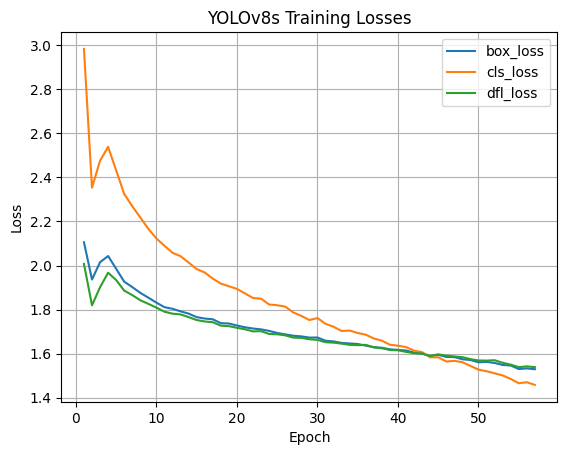

In [3]:
# Plot the training loss curves
plt.figure()
plt.plot(df["epoch"], df["train/box_loss"], label="box_loss")
plt.plot(df["epoch"], df["train/cls_loss"], label="cls_loss")
plt.plot(df["epoch"], df["train/dfl_loss"], label="dfl_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("YOLOv8s Training Losses")
plt.legend()
plt.grid(True)
plt.show()

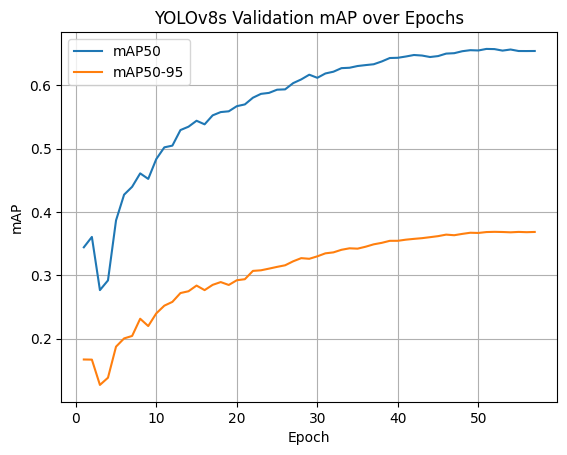

In [4]:
# Plot mAP curve
plt.figure()
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("YOLOv8s Validation mAP over Epochs")
plt.legend()
plt.grid(True)
plt.show()

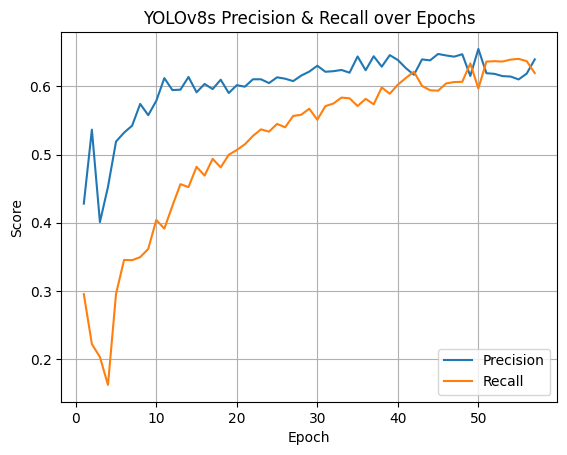

In [5]:
# Plot Precision/Recall curve
plt.figure()
plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("YOLOv8s Precision & Recall over Epochs")
plt.legend()
plt.grid(True)
plt.show()

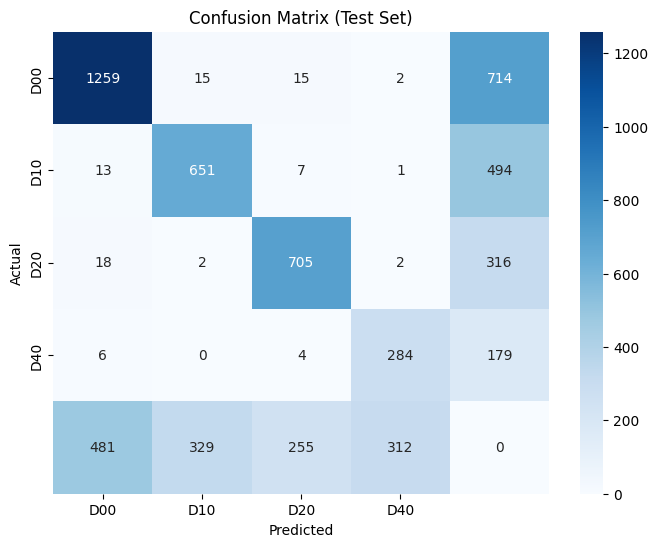

In [12]:
cm = test_metrics.confusion_matrix.matrix
labels = list(test_metrics.names.values())  # class names

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".0f", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test Set)")
plt.show()

In [9]:
label_dir = "RDD_YOLO/labels/test"
y_true = []
y_pred = []

for r in preds:
    img_name = os.path.basename(r.path)
    label_file = os.path.join(label_dir, img_name.replace(".jpg", ".txt"))

    # Ground truth classes in image
    gt_classes = []
    if os.path.exists(label_file):
        with open(label_file) as f:
            for line in f:
                gt_classes.append(int(line.split()[0]))

    if len(gt_classes) == 0:
        continue

    # Choose majority GT class
    gt_label = max(set(gt_classes), key=gt_classes.count)

    # Predicted classes in image
    if r.boxes is not None and len(r.boxes.cls) > 0:
        pred_classes = r.boxes.cls.cpu().numpy().astype(int)
        pred_label = max(set(pred_classes), key=list(pred_classes).count)
    else:
        pred_label = gt_label  # or skip image

    y_true.append(gt_label)
    y_pred.append(pred_label)

print(classification_report(y_true, y_pred, target_names=list(model.names.values())))

              precision    recall  f1-score   support

         D00       0.93      0.90      0.92      1019
         D10       0.83      0.76      0.79       355
         D20       0.82      0.92      0.87       514
         D40       0.85      0.84      0.85       198

    accuracy                           0.88      2086
   macro avg       0.86      0.86      0.86      2086
weighted avg       0.88      0.88      0.88      2086



# **YOLOv8m MODEL**

In [13]:
print(torch.cuda.is_available())
print(torch.cuda.device_count())

True
1


In [3]:
model = YOLO("yolov8m.pt")

model.info(detailed=True)

layer                                    name                type  gradient  parameters               shape        mu     sigma
    0                     model.0.conv.weight              Conv2d     False        1296       [48, 3, 3, 3]  -0.00132     0.112        float32
    1                       model.0.bn.weight         BatchNorm2d     False          48                [48]      3.25     0.805        float32
    1                         model.0.bn.bias         BatchNorm2d     False          48                [48]   -0.0758      2.28        float32
    2                             model.0.act                SiLU     False           0                  []         -         -              -
    3                     model.1.conv.weight              Conv2d     False       41472      [96, 48, 3, 3] -0.000509    0.0235        float32
    4                       model.1.bn.weight         BatchNorm2d     False          96                [96]      2.95     0.632        float32
    4         

(169, 25902640, 0, 79.3204224)

In [ ]:
model = YOLO("yolov8m.pt")

results = model.train(
    data="rdd.yaml",
    epochs=60,
    imgsz=640,
    batch=16,
    workers=4,
    device="cuda",
    conf=0.25,
    max_det=100,
    patience=10,
    flipud=0.0,      # vertical flip prob
    fliplr=0.5,      # horizontal flip prob
    scale=0.2,       # random scale
    degrees=5.0,     # small rotation
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    mosaic=0.5,
    mixup=0.1,
)

Ultralytics 8.3.235  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=0.25, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=rdd.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=100, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=0.5, multi_scale=False, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspective=0.0, plots=True, pose=1

In [2]:
model = YOLO("runs/detect/train3/weights/last.pt")
model.train(resume=True)

New https://pypi.org/project/ultralytics/8.3.236 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.235  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=0.25, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=rdd.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=100, mixup=0.1, mode=train, model=runs\detect\train3\weights\last.pt, momentum=0.937, mosaic=0.5, multi_scale=False, name=train3, nbs=6

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000118B7664D40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
       

In [4]:
# Test on test set
model = YOLO("runs/detect/train3/weights/best.pt")

test_metrics = model.val(
    data="rdd.yaml",
    split="test", # use test split from yaml
    imgsz=640,
    conf=0.25,
    max_det=100,
    device="cuda", # "cuda" on Windows, "cpu" if no GPU
    plots=True, # saves confusion matrix, PR curve, etc.
    save_json=True # optional, COCO-style metrics
)

print(test_metrics) 

Ultralytics 8.3.235  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
Model summary (fused): 92 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access  (ping: 0.20.0 ms, read: 30.614.9 MB/s, size: 69.3 KB)
val: Scanning C:\Users\USER\Documents\YOLO_Project\RDD_YOLO\labels\test... 2086 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2086/2086 769.9it/s 2.7s.1ss
val: New cache created: C:\Users\USER\Documents\YOLO_Project\RDD_YOLO\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 131/131 2.2it/s 58.5s0.6ss
                   all       2086       4361      0.685      0.597       0.66      0.366
                   D00       1149       1777      0.704      0.654      0.705      0.418
                   D10        647        997      0.652      0.594       0.63      0.328
                   D20        798        986      0.715      0.664      0.735      

In [21]:
model = YOLO("runs/detect/train3/weights/best.pt")

preds = model.predict(
    source="RDD_YOLO/images/test",  # path to test images
    imgsz=640,
    conf=0.5,
    iou=0.7, 
    device="cuda",
    save=False
)


WARNING 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/2086 C:\Users\USER\Documents\YOLO_Project\RDD_YOLO\images\test\China_Drone_000003.jpg: 640x640 2 D10s, 22.7ms
image 2/2086 C:\Users\USER\Documents\YOLO_Project\RDD_YOLO\images\test\China_Drone_000035.jpg: 640x640 (no detections), 24.0ms
image 3/2086 C:\Users\USER\Documents\YOLO_Project\RDD_YOLO\images\test\China_Drone_000039.jpg: 640x640 1 D10, 20.0ms
image 4/2086 C:\Users\USER\Documents\YOLO_Project\RDD_YOLO\images\test\China_Drone_000040.jpg: 64

In [4]:
df = pd.read_csv("runs/detect/train5/results.csv")
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
55,56,3534.46,1.26084,1.04851,1.39790,0.66902,0.61479,0.66059,0.37425,1.70045,1.30830,1.70773,0.000925,0.000925,0.000925
56,57,4427.40,1.25356,1.02857,1.39440,0.66346,0.61389,0.66001,0.37320,1.70504,1.31005,1.71432,0.000760,0.000760,0.000760
57,58,5707.23,1.24530,1.02682,1.39079,0.66496,0.61308,0.65838,0.37267,1.70867,1.31156,1.72037,0.000595,0.000595,0.000595
58,59,6643.58,1.23046,1.00031,1.37896,0.66264,0.61113,0.65731,0.37195,1.71320,1.31319,1.72716,0.000430,0.000430,0.000430
59,60,7649.79,1.22571,1.00467,1.37930,0.66577,0.60620,0.65635,0.37107,1.71666,1.31424,1.73258,0.000265,0.000265,0.000265


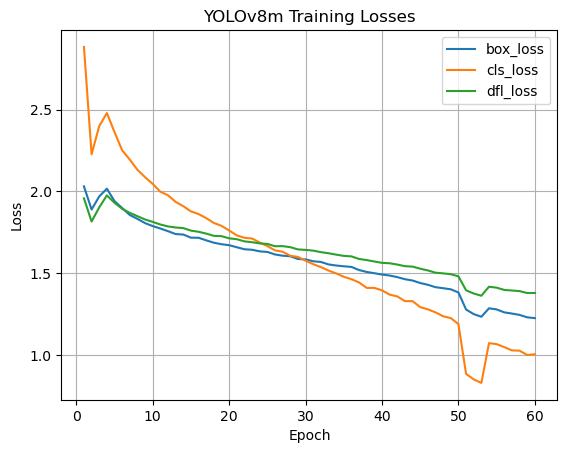

In [5]:
# Plot the training loss curves
plt.figure()
plt.plot(df["epoch"], df["train/box_loss"], label="box_loss")
plt.plot(df["epoch"], df["train/cls_loss"], label="cls_loss")
plt.plot(df["epoch"], df["train/dfl_loss"], label="dfl_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("YOLOv8m Training Losses")
plt.legend()
plt.grid(True)
plt.show()

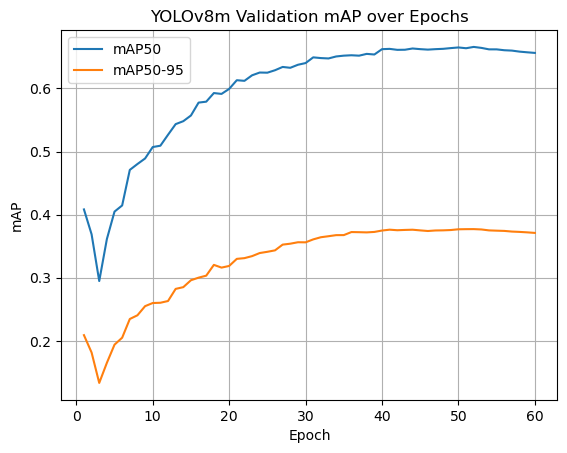

In [6]:
# Plot mAP curve
plt.figure()
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("YOLOv8m Validation mAP over Epochs")
plt.legend()
plt.grid(True)
plt.show()

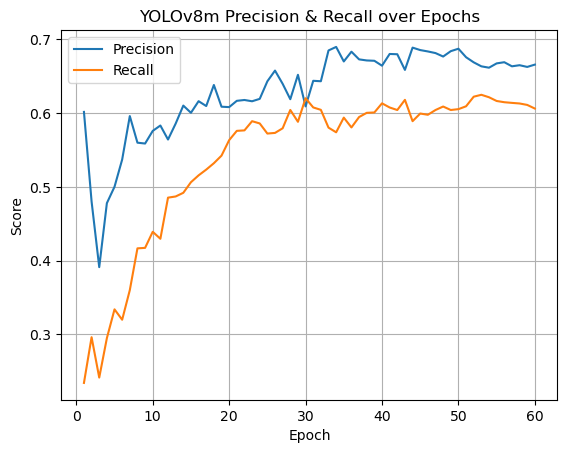

In [7]:
# Plot Precision/Recall curve
plt.figure()
plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("YOLOv8m Precision & Recall over Epochs")
plt.legend()
plt.grid(True)
plt.show()

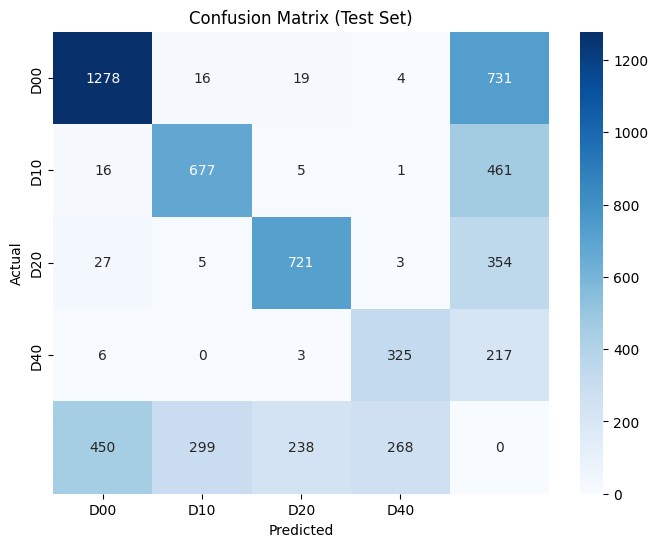

In [15]:
cm = test_metrics.confusion_matrix.matrix
labels = list(test_metrics.names.values())  # class names

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".0f", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test Set)")
plt.show()

In [24]:
y_true = []
y_pred = []

label_dir = "RDD_YOLO/labels/test"
class_names = list(model.names.values())

for r in preds:
    img_name = os.path.basename(r.path)
    label_file = os.path.join(label_dir, img_name.replace(".jpg", ".txt"))

    # ---- Ground truth (one label per image) ----
    if os.path.exists(label_file):
        with open(label_file) as f:
            gt_label = int(f.readline().split()[0])  # take first object class
    else:
        continue  # skip images with no GT

    # ---- Prediction (choose the most frequent predicted class) ----
    if r.boxes is not None and len(r.boxes) > 0:
        pred_classes = r.boxes.cls.cpu().numpy().astype(int)
        pred_label = max(set(pred_classes), key=list(pred_classes).count)
    else:
        pred_label = gt_label  # OR skip, but this keeps lengths equal

    y_true.append(gt_label)
    y_pred.append(pred_label)

# ---- Print report ----
print(classification_report(y_true, y_pred, target_names=class_names))


              precision    recall  f1-score   support

         D00       0.82      0.91      0.86       872
         D10       0.71      0.69      0.70       358
         D20       0.86      0.80      0.83       615
         D40       0.88      0.75      0.81       241

    accuracy                           0.82      2086
   macro avg       0.82      0.79      0.80      2086
weighted avg       0.82      0.82      0.82      2086

